In [1]:
%load_ext autoreload
%autoreload 2

In [2]:

import spacy
import lftk
print(dir(spacy))         # you need tokens to appear, otherwise youre fucked
print(spacy.__version__)
print(spacy.__file__)

['Any', 'Config', 'ConfigSchema', 'ConfigSchemaInit', 'ConfigSchemaNlp', 'ConfigSchemaPretrain', 'ConfigSchemaTraining', 'Dict', 'Errors', 'Example', 'Iterable', 'Language', 'Path', 'REGISTRY_POPULATED', 'Union', 'Vocab', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', '_rebuild_ns', '_schema', 'about', 'attrs', 'blank', 'cli', 'compat', 'displacy', 'errors', 'explain', 'git_info', 'glossary', 'info', 'kb', 'lang', 'language', 'lexeme', 'load', 'logger', 'lookups', 'matcher', 'ml', 'morphology', 'parts_of_speech', 'pipe_analysis', 'pipeline', 'populate_registry', 'prefer_gpu', 'registrations', 'registry', 'require_cpu', 'require_gpu', 'schemas', 'scorer', 'setup_default_warnings', 'strings', 'symbols', 'sys', 'tokenizer', 'tokens', 'training', 'ty', 'util', 'vectors', 'vocab']
3.8.13
/Users/maxwellchamplin/Documents/GitHub/NLP_and_Identity_project1/.venv/lib/python3.11/site-packages/spacy/__init__.py


In [3]:
import sys
try:
    del sys.modules['CorpusLoadAndFilter']
except KeyError:
    pass
import CorpusLoadAndFilter as CLF




[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/maxwellchamplin/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
/Users/maxwellchamplin/Documents/GitHub/NLP_and_Identity_project1/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Corpus ready to be analyszed, file loaded correctly


In [16]:
desiredLength = 5000
teen_corpus = CLF.load_corpus("teenagers",desiredLength)
PhD_corpus = CLF.load_corpus("PhD",desiredLength)

CLF.features_to_csv(teen_corpus,'Analysis1corpus.csv')
CLF.features_to_csv(PhD_corpus,'Analysis2corpus.csv')

teen_corpus = CLF.tokenize(teen_corpus)
PhD_corpus = CLF.tokenize(PhD_corpus)

In [17]:
CLF.transform_corpus(teen_corpus,'Analysis1corpus.csv')
CLF.transform_corpus(PhD_corpus,'Analysis2corpus.csv')

teen_dataframe = teen_corpus.get_utterances_dataframe()

PhD_dataframe = PhD_corpus.get_utterances_dataframe()

teen_dataframe = teen_dataframe[(teen_dataframe['meta.num_tokens'] > 10) & (teen_dataframe['meta.num_tokens'] < 500)]
PhD_dataframe = PhD_dataframe[(PhD_dataframe['meta.num_tokens'] > 10) & (PhD_dataframe['meta.num_tokens'] < 500)]

#print('number of Rows in Teen data',len(teen_dataframe))
#print('number of rows in PHD data',len(PhD_dataframe))

#PhD_dataframe.head(20)

/Users/maxwellchamplin/Documents/GitHub/NLP_and_Identity_project1/CorpusLoadAndFilter.py:138: RuntimeWarning: invalid value encountered in scalar divide
  value = value / utt.meta['num_tokens']
/Users/maxwellchamplin/Documents/GitHub/NLP_and_Identity_project1/CorpusLoadAndFilter.py:138: RuntimeWarning: invalid value encountered in scalar divide
  value = value / utt.meta['num_tokens']


In [18]:
PhD_dataframe.to_csv('phd_csv.csv')
teen_dataframe.to_csv('teen_csv.csv')
import polars as pl
import stanza
import elfen

nlp = stanza.Pipeline('en')
from elfen.extractor import Extractor


2026-03-26 13:08:25 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES
2026-03-26 13:08:25 INFO: Downloaded file to /Users/maxwellchamplin/Library/Caches/stanza/1.11.0/resources/resources.json
2026-03-26 13:08:26 INFO: Loading these models for language: en (English):
| Processor    | Package                   |
--------------------------------------------
| tokenize     | combined                  |
| mwt          | combined                  |
| pos          | combined_charlm           |
| lemma        | combined_nocharlm         |
| constituency | ptb3-revised_charlm       |
| depparse     | combined_charlm           |
| sentiment    | sstplus_charlm            |
| ner          | ontonotes-ww-multi_charlm |

2026-03-26 13:08:26 INFO: Using device: cpu
2026-03-26 13:08:26 INFO: Loading: tokenize
2026-03-26 13:08:26 INFO: Loading: mwt
2026-03-26 

In [20]:
#testing this as a csv, cause elfen wants csvs. 
df_phd = pl.read_csv('phd_csv.csv')
df_teen = pl.read_csv('teen_csv.csv')
#print(df.head())
extractor_phd = Extractor(data=df_phd)
extractor_teen = Extractor(data=df_teen)

extractor_phd.extract_feature_group(feature_group=['lexical_richness','pos','surface','emotion','semantic'])
extractor_teen.extract_feature_group(feature_group=['lexical_richness','pos','surface','emotion','semantic'])
#features = extractor.extract_features()


#extractor_phd.normalize('all')
#extractor_teen.normalize('all')
teen_frame = extractor_teen.get_data()
phd_frame = extractor_phd.get_data()
phd_pandas = phd_frame.to_pandas()
teen_pandas = teen_frame.to_pandas()
phd_pandas.to_csv('phd_elfen.csv')
teen_pandas.to_csv('teen_elfen.csv')


/Users/maxwellchamplin/Documents/GitHub/NLP_and_Identity_project1/.venv/lib/python3.11/site-packages/elfen/emotion.py:761: UserWarning: Some texts do not contain any words from the VAD lexicon. The standard deviation of valence for these texts is set to None/null. You may want to consider filling nulls with a specific value.
  warnings.warn(
/Users/maxwellchamplin/Documents/GitHub/NLP_and_Identity_project1/.venv/lib/python3.11/site-packages/elfen/emotion.py:911: UserWarning: Some texts do not contain any words from the VAD lexicon. The standard deviation of arousal for these texts is set to None/null. You may want to consider filling nulls with a specific value.
  warnings.warn(
/Users/maxwellchamplin/Documents/GitHub/NLP_and_Identity_project1/.venv/lib/python3.11/site-packages/elfen/emotion.py:1060: UserWarning: Some texts do not contain any words from the VAD lexicon. The standard deviation of dominance for these texts is set to None/null. You may want to consider filling nulls with 

In [27]:
phd_frame.glimpse()

Rows: 3286
Columns: 208
$ id                                     <str> '1f1oov', '5wvoi0', '5x2ami', '5x2upl', '5xh22v', '5xjdfh', '5xjf3t', '5xkghq', '5xlpws', '5xq9j8'
$ timestamp                              <i64> 1369514339, 1488374128, 1488446723, 1488456610, 1488636818, 1488664269, 1488664854, 1488678227, 1488697982, 1488761432
$ text                                   <str> "I'm looking for a Masters/PhD program that looks at Human (Capital) Development, Organizational Systems, Business and Social Architecture, and Design Thinking.\n\n There's the Institute of Design in Chicago:\nhttps://www.id.iit.edu/\n\nand Private Centres such as the Fielding Institute which offer programs such as Human and Organizational Systems.\n\nhttp://www.fielding.edu/programs/human-organizational-development/hos\nBut both are far and too expensive.  I'd need a public university - preferably in Toronto - that costs less and can provide funding.  Any suggestions?\n", "I'm currently in the early stages of

In [ ]:
teen_frame.glimpse()

In [21]:
import pandas as pd 
phd_pandas = pd.read_csv('phd_elfen.csv')

teen_pandas = pd.read_csv('teen_elfen.csv')

In [66]:
def compare_stats(df1, df2, column, labels=('Teenagers', 'PhD')):
    """Print median and standard deviation of a column across two dataframes"""
    if column not in df1.columns or column not in df2.columns:
        raise ValueError(f"Column '{column}' not found in both dataframes.")
    
    data1 = df1[column].dropna()
    data2 = df2[column].dropna()
    
    print(f"--- {column} ---")
    print(f"{labels[0]:<20} median: {data1.median():.4f}  std: {data1.std():.4f}")
    print(f"{labels[1]:<20} median: {data2.median():.4f}  std: {data2.std():.4f}")
    

def compare_stats_title(df1, df2, column, labels=('Teenagers', 'PhD')):
    """Print median and standard deviation of a column across two dataframes"""
    if column not in df1.columns or column not in df2.columns:
        raise ValueError(f"Column '{column}' not found in both dataframes.")
    
    data1 = df1[column].dropna()
    data2 = df2[column].dropna()
    
    title = (f"{column}\n"
             f"{labels[0]} — median: {data1.median():.4f}  std: {data1.std():.4f}\n"
             f"{labels[1]} — median: {data2.median():.4f}  std: {data2.std():.4f}")
    
    print(title)
    return title


In [72]:
import matplotlib.pyplot as plt


def violin_plot(df, column, title=None, color='steelblue'):
    if column not in df.columns:
        raise ValueError(f"Column '{column}' not found in dataframe. Available columns: {list(df.columns)}")
    
    data = df[column].dropna()
    
    fig, ax = plt.subplots(figsize=(6, 8))
    
    ax.violinplot(data, showmedians=True, showextrema=True)
    
    ax.set_title(title if title else column)
    ax.set_xticks([1])
    ax.set_xticklabels([column])
    ax.set_ylabel('Value')
    plt.Colorizer(color)
    plt.tight_layout()
    plt.show()



def violin_plot_compare(df1, df2, column, labels=('Teenagers', 'PhD'), title=None, colors=('steelblue', 'coral')):
    """Compare the same column across two dataframes"""
    if column not in df1.columns or column not in df2.columns:
        raise ValueError(f"Column '{column}' not found in both dataframes.")
    
    data = [df1[column].dropna(), df2[column].dropna()]
    
    fig, ax = plt.subplots(figsize=(8, 8))
    
    parts = ax.violinplot(data, showmedians=True, showextrema=True)
    
    # Apply colors to each violin
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(colors[i])
        pc.set_alpha(0.7)
    
    # Color the median lines and extrema to match
    for partname in ('cmedians', 'cmins', 'cmaxes', 'cbars'):
        parts[partname].set_edgecolor('dimgray')
    
    
    
    ax.set_title(compare_stats_title(df1,df2,column=column))
    ax.set_xticks([1, 2])
    ax.set_xticklabels(labels)
    ax.set_ylabel('Value')
    
    plt.tight_layout()
    plt.show()
    
    


In [83]:
def violin_plot_compare_cutoff(df1, df2, column, cutoff=None, labels=('Teenagers', 'PhD'), 
                                title=None, colors=('steelblue', 'coral')):
   
    if column not in df1.columns or column not in df2.columns:
        raise ValueError(f"Column '{column}' not found in both dataframes.")
    
    data1 = df1[column].dropna()
    data2 = df2[column].dropna()
    
    if cutoff is not None:
        data1 = data1[data1 >= cutoff]
        data2 = data2[data2 >= cutoff]
        cutoff_note = f"(cutoff: ≥{cutoff})"
    else:
        cutoff_note = ""
    
    if len(data1) == 0 or len(data2) == 0:
        raise ValueError(f"No data above cutoff {cutoff} in one or both dataframes.")
    
    fig, ax = plt.subplots(figsize=(8, 8))
    
    parts = ax.violinplot([data1, data2], showmedians=True, showextrema=True)
    
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(colors[i])
        pc.set_alpha(0.7)
    
    for partname in ('cmedians', 'cmins', 'cmaxes', 'cbars'):
        parts[partname].set_edgecolor('dimgray')
    
    ax.set_title(f"{title if title else column} {cutoff_note}")
    ax.set_xticks([1, 2])
    ax.set_xticklabels([f"{labels[0]} (n={len(data1)})", f"{labels[1]} (n={len(data2)})"])
    ax.set_ylabel('Value')
    
    plt.tight_layout()
    plt.show()

sentiment_score
Teenagers — median: 0.0273  std: 0.0369
PhD — median: 0.0135  std: 0.0324


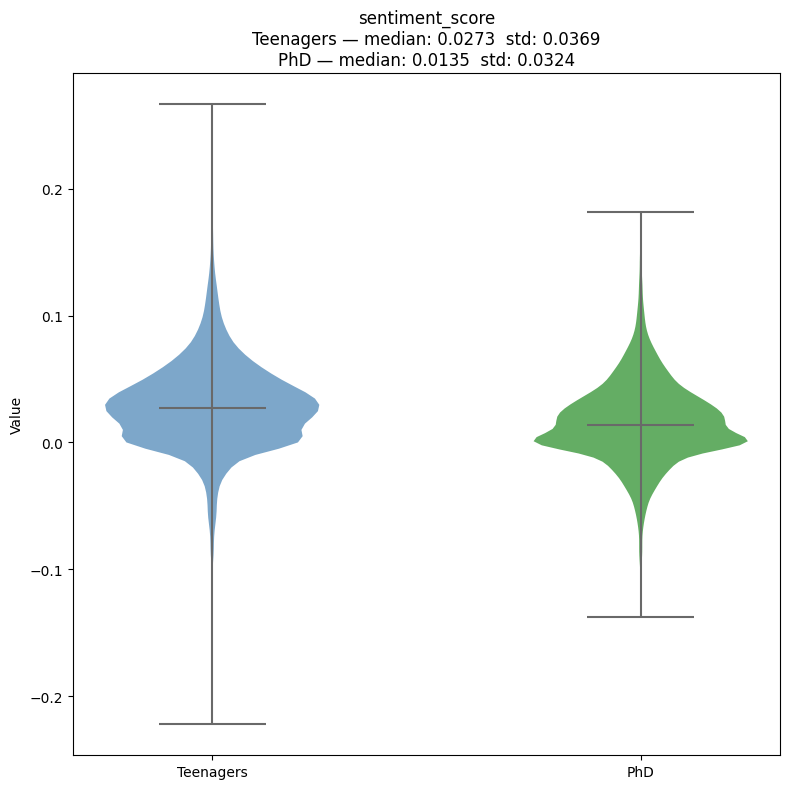

In [73]:
violin_plot_compare(df1 = phd_pandas,df2=teen_pandas,column = 'sentiment_score',colors=('steelblue','forestgreen'))

avg_intensity_anger
Teenagers — median: 0.0000  std: 0.2741
PhD — median: 0.0000  std: 0.2349


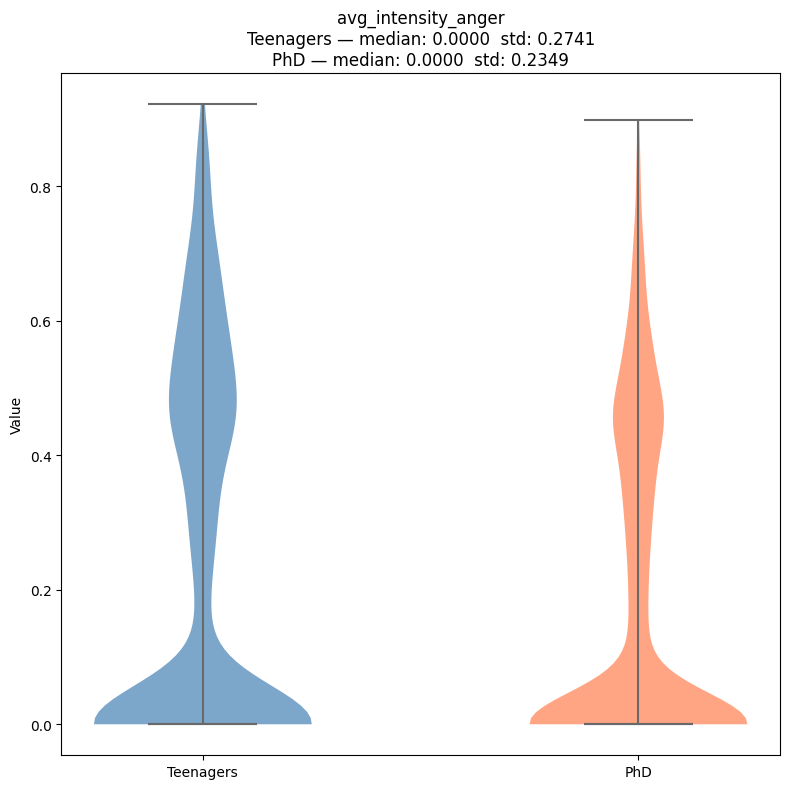

In [82]:
violin_plot_compare(teen_pandas,phd_pandas,'avg_intensity_anger')

pos_variability
Teenagers — median: 0.1765  std: 0.1453
PhD — median: 0.1519  std: 0.1507


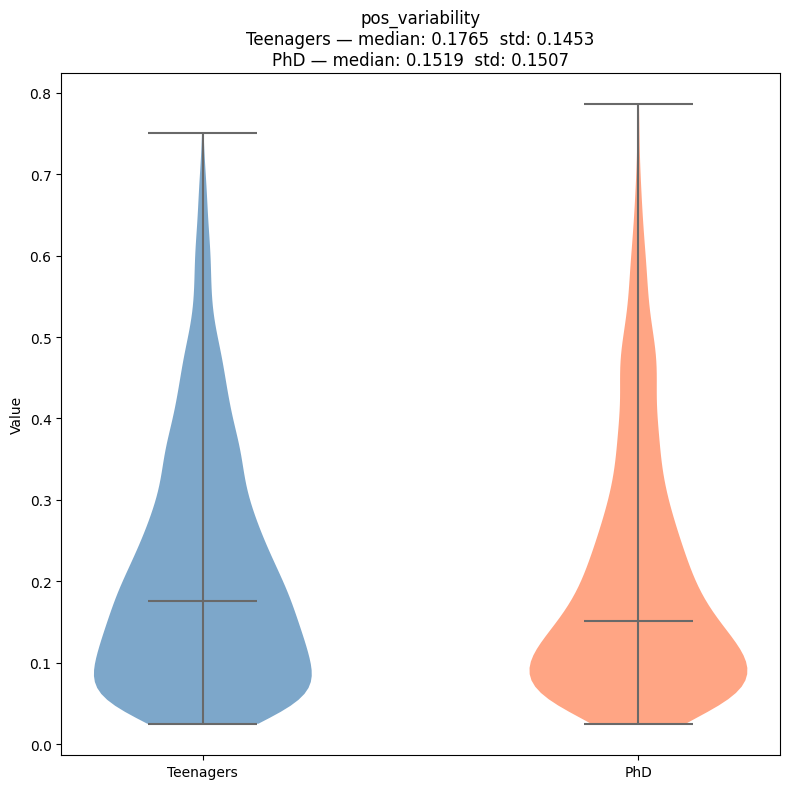

In [81]:
violin_plot_compare(teen_pandas,phd_pandas,'pos_variability')


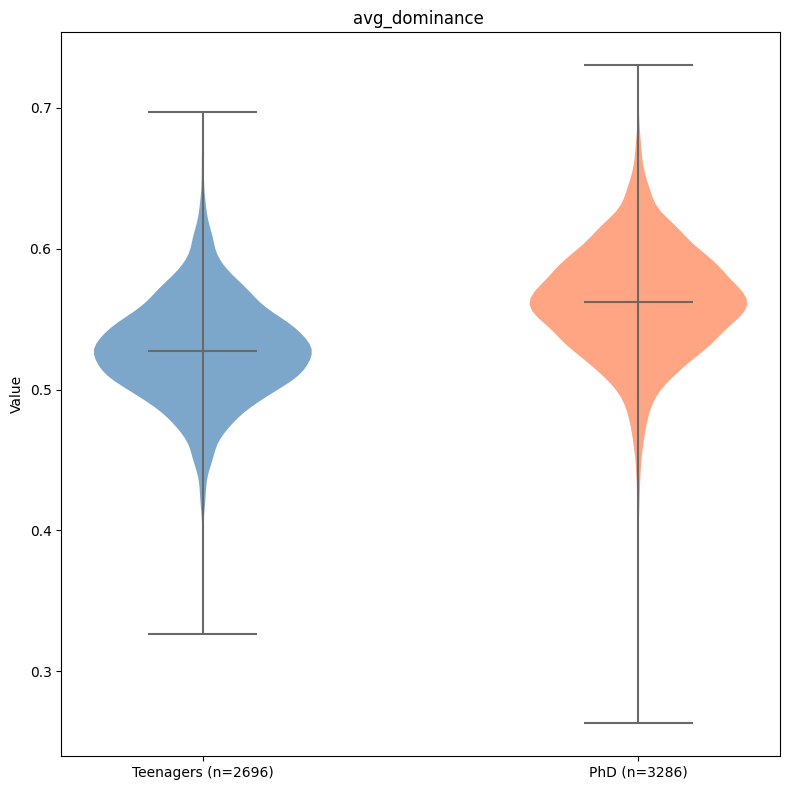

In [93]:
violin_plot_compare_cutoff(teen_pandas,phd_pandas,'avg_dominance',cutoff=None)